<a href="https://colab.research.google.com/github/falseywinchnet/EpistemicGPT/blob/main/RopePlayground.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

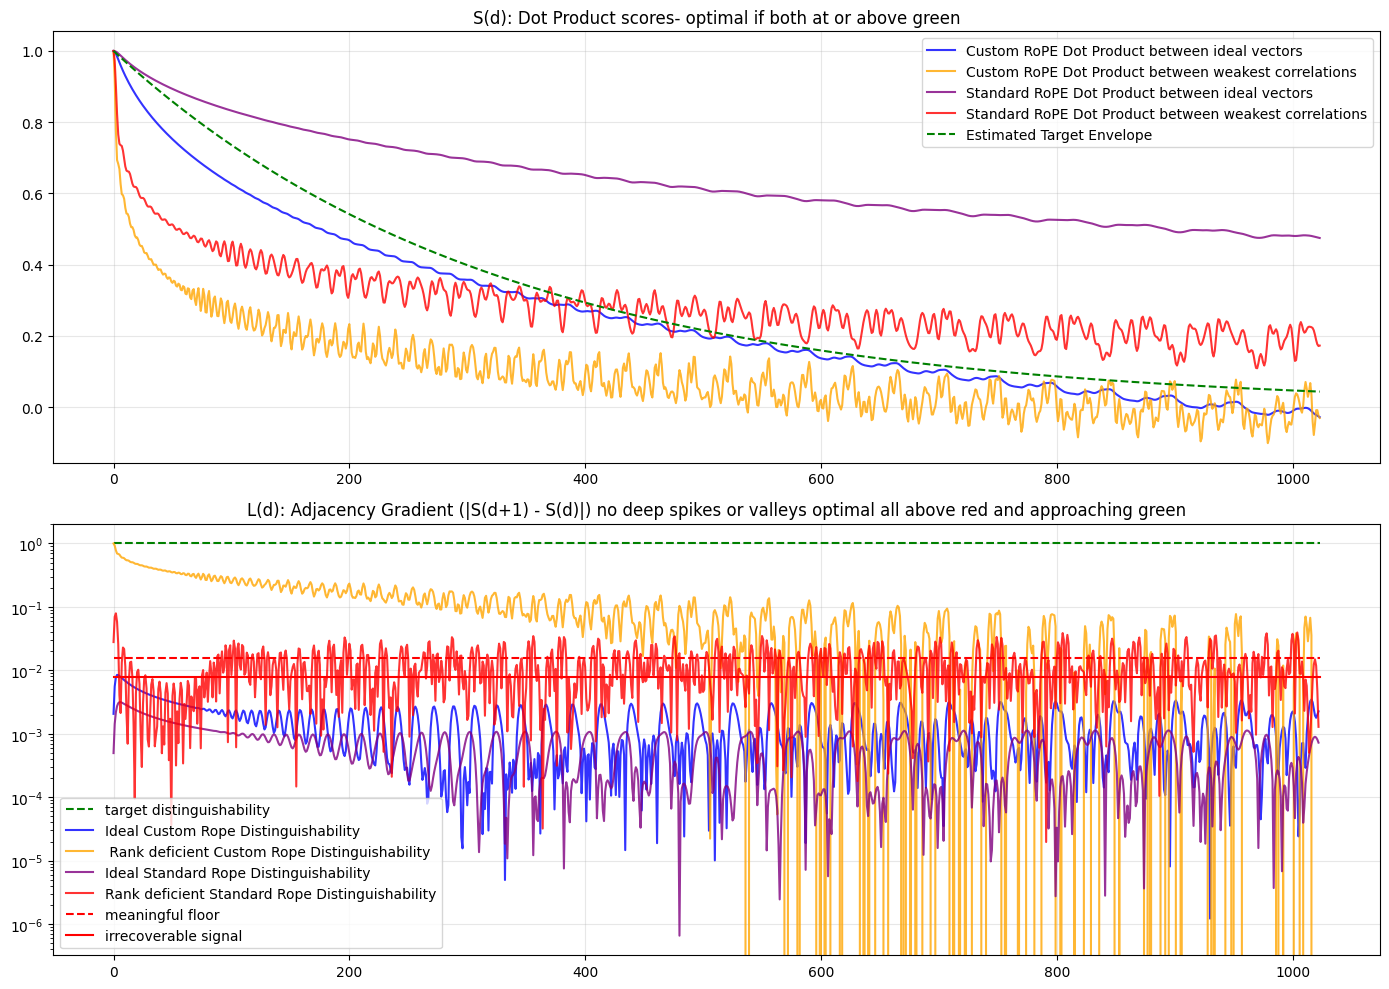

In [ ]:
import torch
import matplotlib.pyplot as plt

# Configuration
dim = 256
length = 1024
w_max = torch.pi / 2
w_min = torch.pi / (length * 4)

# Frequencies for the dim/2 components
base_logs = torch.linspace(torch.log(torch.tensor(w_max)), torch.log(torch.tensor(w_min)), dim // 2)
freqs = torch.exp(base_logs)
# Standard RoPE Configuration
base = 10000.0
# Compute indices j: [0, 1, 2, ..., dim/2 - 1]
j = torch.arange(0, dim // 2).float()

# Standard formula: theta_j = base^(-2j / dim)
freqs_standard = torch.pow(base, -(2 * j / dim))

def rotate_half(x):
    # Standard implementation: [-x1, x0, -x3, x2, ...]
    x1 = x[..., 0::2]
    x2 = x[..., 1::2]
    return torch.stack((-x2, x1), dim=-1).flatten()

def apply_rope_interleaved(x, pos, freqs):
    # Expand freqs to match the interleaved format [f0, f0, f1, f1, ...]
    emb = torch.stack((freqs, freqs), dim=-1).flatten()
    angles = pos * emb

    cos = torch.cos(angles)
    sin = torch.sin(angles)

    # RoPE formula: x*cos + rotate_half(x)*sin
    return (x * cos) + (rotate_half(x) * sin)

def simulate_good_interaction(freqs, seq_len=length):
    # Initialize Q and K as unit vectors

    torch.manual_seed(42)
    q = torch.arange(dim).float()
    q = q / q.norm()
    k_base = torch.arange(dim).float()
    k_base = k_base / k_base.norm()

    scores = []
    # Q at position 0, K at position d
    q_0 = apply_rope_interleaved(q, 0, freqs)

    for d in range(seq_len):

        k_d = apply_rope_interleaved(k_base, float(d), freqs)
        dot_product = torch.dot(q_0, k_d)
        scores.append(dot_product.item())

    scores = torch.tensor(scores)
    diffs = torch.abs(scores[1:] - scores[:-1])
    return scores, diffs

s_actual, l_actual = simulate_good_interaction(freqs)
s_actual_rope, l_actual_rope = simulate_good_interaction(freqs_standard)


def simulate_weak_interaction(freqs, seq_len=length):
    # Initialize Q and K as unit vectors

    torch.manual_seed(42)
    q = torch.ones(dim).float()
    q = q / q.norm()
    k_base = torch.ones(dim).float()
    k_base = k_base / k_base.norm()

    scores = []
    # Q at position 0, K at position d
    q_0 = apply_rope_interleaved(q, 0, freqs)

    for d in range(seq_len):

        k_d = apply_rope_interleaved(k_base, float(d), freqs)
        dot_product = torch.dot(q_0, k_d)
        scores.append(dot_product.item())

    scores = torch.tensor(scores)
    diffs = torch.abs(scores[1:] - scores[:-1])
    return scores, diffs

s_weak, l_weak = simulate_weak_interaction(freqs)
s_weak_rope, l_weak_rope = simulate_weak_interaction(freqs_standard)

# Target
t = torch.arange(length).float()
target_curve = torch.exp(-(1.0 / (length / 3.14)) * t)

plt.figure(figsize=(14, 10))
plt.subplot(2, 1, 1)
plt.plot(s_actual.numpy(), label='Custom RoPE Dot Product between ideal vectors', color='blue', alpha=0.8)
plt.plot(s_weak.numpy(), label='Custom RoPE Dot Product between weakest correlations', color='orange', alpha=0.8)
plt.plot(s_actual_rope.numpy(), label='Standard RoPE Dot Product between ideal vectors', color='purple', alpha=0.8)
plt.plot(s_weak_rope.numpy(), label='Standard RoPE Dot Product between weakest correlations', color='red', alpha=0.8)


plt.plot(target_curve.numpy(), label='Estimated Target Envelope', color='green', linestyle='--')
plt.title("S(d): Dot Product scores- optimal if both at or above green")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(torch.ones(length), label='target distinguishability', color='green', linestyle='--')
plt.plot(l_actual.numpy(), label='Ideal Custom Rope Distinguishability', color='blue', alpha=0.8)
plt.plot(s_weak.numpy(), label=' Rank deficient Custom Rope Distinguishability', color='orange', alpha=0.8)
plt.plot(l_actual_rope.numpy(), label='Ideal Standard Rope Distinguishability', color='purple', alpha=0.8)
plt.plot(l_weak_rope.numpy(), label='Rank deficient Standard Rope Distinguishability', color='red', alpha=0.8)
plt.plot((torch.ones(length) *torch.sqrt(torch.tensor(dim).float())  *  2**-10).numpy(), label='meaningful floor', color='red', linestyle='--')
plt.plot(torch.ones(length).numpy()*(1/(dim//2)), label='irrecoverable signal', color='red')

plt.yscale('log')
plt.title("L(d): Adjacency Gradient (|S(d+1) - S(d)|) no deep spikes or valleys optimal all above red and approaching green")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

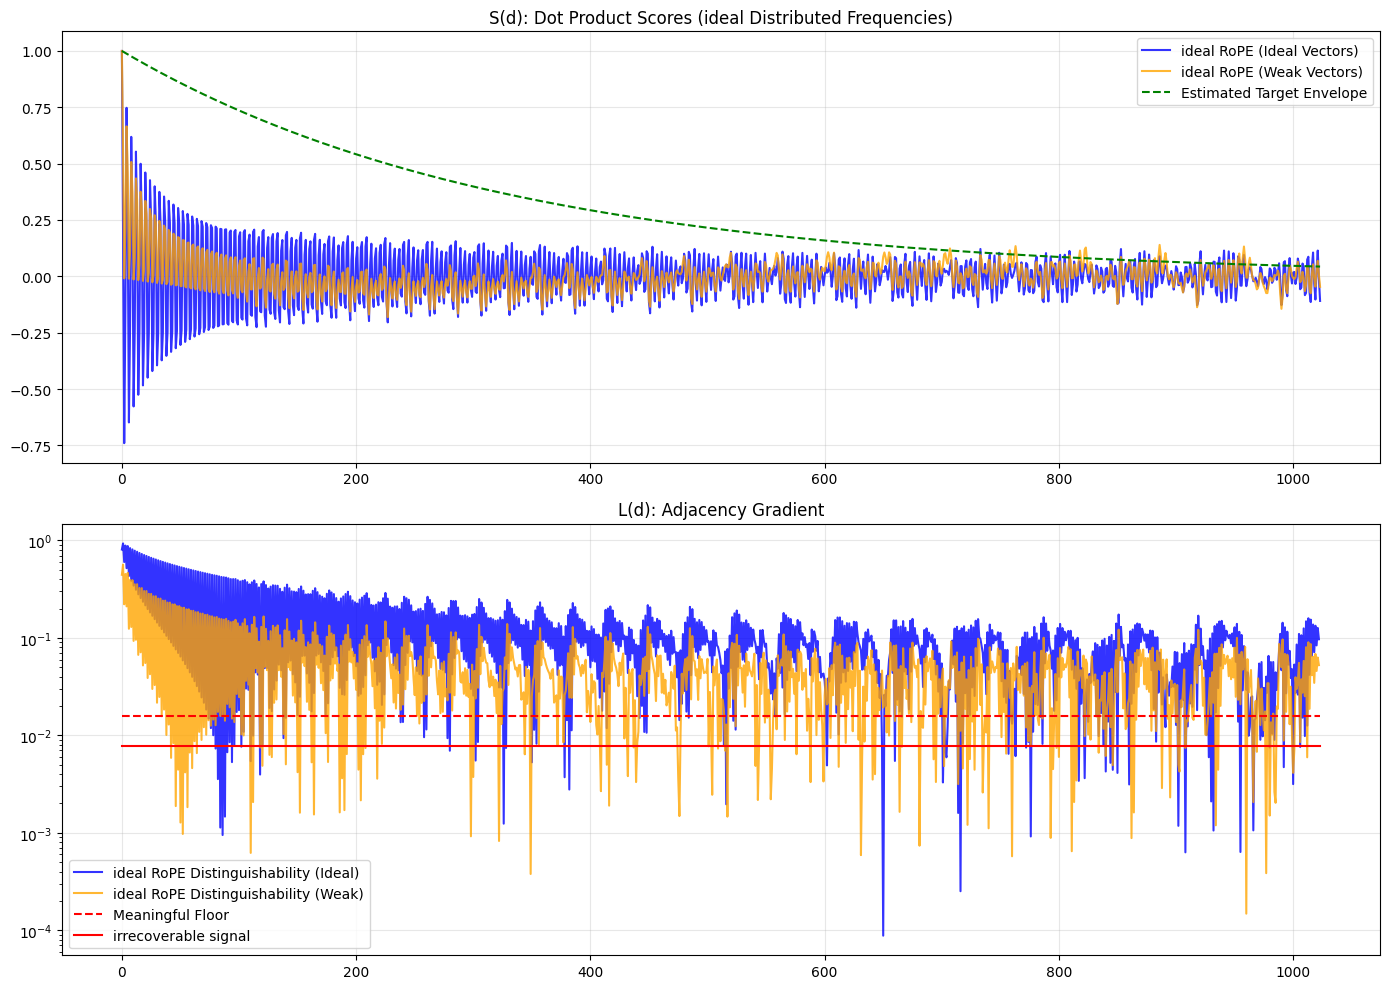

In [ ]:
import torch
import matplotlib.pyplot as plt
import math
# Configuration
dim = 256
length = 1024

w_max = (math.pi / 2.0)
w_min = (math.pi / (length * 4.0))
setfreqs_hi = torch.logspace(
            start=0,
            end=math.log10(dim // 2),
            steps=(dim // 4),
            base=10.0
        )

        # Dense Low Frequencies (End)
        # We invert the logspace to pack density at the 'dim' end
setfreqs_lo = dim - torch.logspace(
    start=0,
    end=math.log10(dim // 2),
    steps=(dim // 4) + 1,
    base=10.0
)[:-1] # Drop last to match size

        # Combine
setfreqs = torch.cat((setfreqs_hi, setfreqs_lo))

        # Sort Ascending (Small index = High Freq / Large index = Low Freq)
setfreqs, _ = torch.sort(setfreqs, descending=False)

#scale setfreqs to between 0 and 1
setfreqs = setfreqs - setfreqs.min() / (setfreqs.max() - setfreqs.min())

freqs = (setfreqs)
freqs =  freqs - freqs.min() / (freqs.max() - freqs.min())
freqs = w_min + (w_max - w_min) * (freqs / freqs.max())
freqs, _ = torch.sort(freqs,descending=False)


# --- Standard Helper Functions (Unchanged) ---
def rotate_half(x):
    x1 = x[..., 0::2]
    x2 = x[..., 1::2]
    return torch.stack((-x2, x1), dim=-1).flatten()

def apply_rope_interleaved(x, pos, freqs):
    emb = torch.stack((freqs, freqs), dim=-1).flatten()
    angles = pos * emb
    cos = torch.cos(angles)
    sin = torch.sin(angles)
    return (x * cos) + (rotate_half(x) * sin)

def simulate_interaction(freqs, seq_len=length, ideal=True):
    torch.manual_seed(42)
    if ideal:
        q = torch.arange(dim).float(); q = q / q.norm()
        k_base = torch.arange(dim).float(); k_base = k_base / k_base.norm()
    else: # Weak/Rank Deficient
        q = torch.ones(dim).float(); q = q / q.norm()
        k_base = torch.ones(dim).float(); k_base = k_base / k_base.norm()

    scores = []
    q_0 = apply_rope_interleaved(q, 0, freqs)
    for d in range(seq_len):
        k_d = apply_rope_interleaved(k_base, float(d), freqs)
        scores.append(torch.dot(q_0, k_d).item())

    scores = torch.tensor(scores)
    diffs = torch.abs(scores[1:] - scores[:-1])
    return scores, diffs

# --- Simulation & Plotting ---
s_ideal, l_ideal = simulate_interaction(freqs, ideal=True)
s_weak, l_weak = simulate_interaction(freqs, ideal=False)

t = torch.arange(length).float()
plt.figure(figsize=(14, 10))
target_curve = torch.exp(-(1.0 / (length / 3.14)) * t)
# Plot 1: S(d)
plt.subplot(2, 1, 1)
plt.plot(s_ideal.numpy(), label='ideal RoPE (Ideal Vectors)', color='blue', alpha=0.8)
plt.plot(s_weak.numpy(), label='ideal RoPE (Weak Vectors)', color='orange', alpha=0.8)
plt.plot(target_curve.numpy(), label='Estimated Target Envelope', color='green', linestyle='--')
plt.title(f"S(d): Dot Product Scores (ideal Distributed Frequencies)")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: L(d)
plt.subplot(2, 1, 2)
plt.plot(l_ideal.numpy(), label='ideal RoPE Distinguishability (Ideal)', color='blue', alpha=0.8)
plt.plot(l_weak.numpy(), label='ideal RoPE Distinguishability (Weak)', color='orange', alpha=0.8)
plt.plot((torch.ones(length) * torch.sqrt(torch.tensor(dim).float()) * 2**-10).numpy(), label='Meaningful Floor', color='red', linestyle='--')
plt.plot(torch.ones(length).numpy()*(1/(dim//2)), label='irrecoverable signal', color='red')

plt.yscale('log')
plt.title("L(d): Adjacency Gradient")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()